# Risco de Crédito — Classificação Binária (Regressão Logística)

**Objetivo:** prever se um tomador de crédito vai apresentar inadimplência séria nos próximos 2
anos (`SeriousDlqin2yrs`), a partir de dados cadastrais e de comportamento de crédito. É um
problema clássico de **classificação binária** — ao lado dos projetos de regressão (elasticidade,
precificação dinâmica) e do de clustering (Iris), cobre as três famílias principais de problema
de ML deste portfólio.

**Conexão com o TCC:** uso a mesma técnica do meu TCC — **Regressão Logística Binária e Razões de
Chance (Odds Ratios)** — só que aqui aplicada a dados de crédito em vez de comportamento de
investidores.

**Dataset:** "Give Me Some Credit" (Kaggle) — 150.000 tomadores de crédito, 10 variáveis
preditoras + o rótulo de inadimplência.

## 1. Importação e carregamento dos dados

`cs-test.csv` é o formato de submissão do Kaggle — o rótulo vem vazio, então não serve pra
avaliação local. Uso só `cs-training.csv`, com meu próprio split de treino/teste.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('cs-training.csv', index_col=0)
data.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 2. Dimensões, estrutura e valores nulos

In [2]:
print(data.shape)
data.info()
print("\nValores nulos:\n", data.isnull().sum())

(150000, 11)
<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float

## 3. Distribuição do target

`SeriousDlqin2yrs` = 1 significa que o tomador ficou com atraso sério (90+ dias) em algum crédito
nos 2 anos seguintes. Esse tipo de problema é tipicamente desbalanceado — a maioria dos tomadores
paga em dia.

                  contagem  proporção
SeriousDlqin2yrs                     
0                   139974     0.9332
1                    10026     0.0668


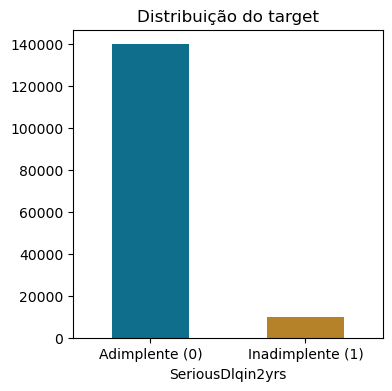

In [3]:
contagem = data['SeriousDlqin2yrs'].value_counts()
proporcao = data['SeriousDlqin2yrs'].value_counts(normalize=True)
print(pd.DataFrame({'contagem': contagem, 'proporção': proporcao.round(4)}))

plt.figure(figsize=(4, 4))
data['SeriousDlqin2yrs'].value_counts().plot(kind='bar', color=['#0f6e8c', '#b5822a'])
plt.xticks([0, 1], ['Adimplente (0)', 'Inadimplente (1)'], rotation=0)
plt.title('Distribuição do target')
plt.show()

## 4. Estatísticas descritivas (procurando inconsistências)

Antes de modelar, vale olhar os valores mínimo/máximo de cada variável — em dados de crédito reais
é comum existirem erros de cadastro (idade zero, taxas impossíveis).

In [4]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


## 5. Inconsistências encontradas

Olhando os extremos do `describe()` acima, dá pra ver alguns valores suspeitos: `age` mínimo 0,
e `RevolvingUtilizationOfUnsecuredLines` (uma taxa que teoricamente deveria ficar perto de 0–1)
com máximo muito acima de 1. Confirmando cada um:

In [5]:
print(f"Linhas com age == 0: {(data['age'] == 0).sum()}")
print(f"Linhas com RevolvingUtilizationOfUnsecuredLines > 1: {(data['RevolvingUtilizationOfUnsecuredLines'] > 1).sum()}")
print(f"Linhas duplicadas: {data.duplicated().sum()}")

cols_atraso = ['NumberOfTime30-59DaysPastDueNotWorse',
               'NumberOfTime60-89DaysPastDueNotWorse',
               'NumberOfTimes90DaysLate']
for col in cols_atraso:
    print(f"\n{col} — maiores valores:", sorted(data[col].unique())[-5:])

Linhas com age == 0: 1
Linhas com RevolvingUtilizationOfUnsecuredLines > 1: 3321
Linhas duplicadas: 609

NumberOfTime30-59DaysPastDueNotWorse — maiores valores: [11, 12, 13, 96, 98]

NumberOfTime60-89DaysPastDueNotWorse — maiores valores: [8, 9, 11, 96, 98]

NumberOfTimes90DaysLate — maiores valores: [14, 15, 17, 96, 98]


## 6. Tratamento dos dados

**Achado interessante nos valores sentinela (96/98):** as 269 linhas com esses códigos nas
colunas de atraso são exatamente as mesmas nas três colunas — não é ruído aleatório, é uma
marcação de sistema (provavelmente "não contabilizado"/erro de cadastro). E olha o detalhe: a
taxa de inadimplência **dentro** desse grupo é de 54,6%, contra 6,7% no restante da base — 8x
maior. Removo essas linhas porque os valores em si não são utilizáveis como contagem real, mas
registro esse achado porque, num cenário real, valeria investigar com a área de negócio por que
esse "erro de sistema" está tão correlacionado com inadimplência.

**Decisões de tratamento:**
- `age == 0` (1 linha): remover — idade zero não existe.
- Sentinela 96/98 nas colunas de atraso (269 linhas): remover.
- `RevolvingUtilizationOfUnsecuredLines > 10` (241 linhas): remover — uma taxa de utilização de
  crédito 10x o limite é inconsistente com dado real, mesmo permitindo alguma margem acima de 1.
- 609 duplicatas: remover.
- `MonthlyIncome` e `NumberOfDependents` (nulos): imputar com a **mediana** — mais robusta a
  outliers que a média, e ambas as colunas têm cauda longa (rendas muito altas puxariam a média
  pra cima).

In [6]:
data_clean = data.copy()

antes = len(data_clean)
data_clean = data_clean[data_clean['age'] > 0]
data_clean = data_clean[~data_clean['NumberOfTime30-59DaysPastDueNotWorse'].isin([96, 98])]
data_clean = data_clean[data_clean['RevolvingUtilizationOfUnsecuredLines'] <= 10]
data_clean = data_clean.drop_duplicates()
print(f"Linhas removidas: {antes - len(data_clean)} ({(antes - len(data_clean)) / antes:.1%})")

data_clean['MonthlyIncome'] = data_clean['MonthlyIncome'].fillna(data_clean['MonthlyIncome'].median())
data_clean['NumberOfDependents'] = data_clean['NumberOfDependents'].fillna(data_clean['NumberOfDependents'].median())

print(f"\nShape final: {data_clean.shape}")
print(f"Nulos restantes: {data_clean.isnull().sum().sum()}")
print(f"Nova taxa de inadimplência: {data_clean['SeriousDlqin2yrs'].mean():.2%}")

Linhas removidas: 1076 (0.7%)

Shape final: (148924, 11)
Nulos restantes: 0
Nova taxa de inadimplência: 6.62%


## 7. Correlação com o target

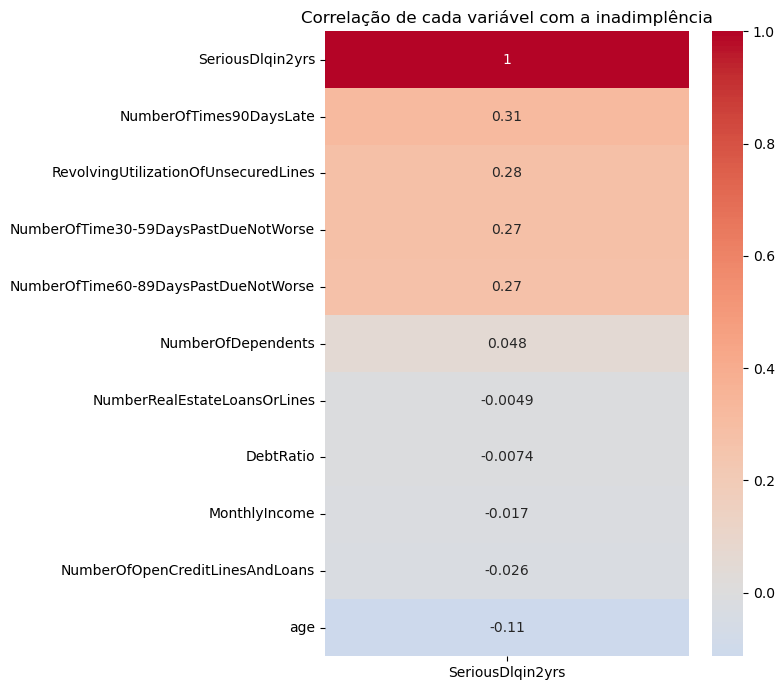

In [7]:
plt.figure(figsize=(8, 7))
corr = data_clean.corr()
sns.heatmap(corr[['SeriousDlqin2yrs']].sort_values('SeriousDlqin2yrs', ascending=False),
            annot=True, cmap='coolwarm', center=0)
plt.title('Correlação de cada variável com a inadimplência')
plt.tight_layout()
plt.show()

## 8. Preparação dos dados

Split treino/teste com `stratify` no target — importante aqui porque o problema é desbalanceado
(≈6-7% de inadimplência); sem estratificar, um split aleatório poderia distorcer essa proporção
entre treino e teste.

In [8]:
from sklearn.model_selection import train_test_split

features = [c for c in data_clean.columns if c != 'SeriousDlqin2yrs']
X = data_clean[features]
y = data_clean['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(f"Taxa de inadimplência — treino: {y_train.mean():.2%} | teste: {y_test.mean():.2%}")

Treino: (119139, 10) | Teste: (29785, 10)
Taxa de inadimplência — treino: 6.62% | teste: 6.62%


## 9. Regressão Logística Binária (statsmodels)

Uso `statsmodels` em vez de ir direto pro `sklearn` porque aqui o objetivo não é só prever — é
**interpretar o efeito de cada variável**, igual fiz no TCC. O `summary()` traz os coeficientes,
p-valores, e a partir deles calculo as **Razões de Chance (Odds Ratios)**.

In [9]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)
modelo_logit = sm.Logit(y_train, X_train_sm).fit()
print(modelo_logit.summary())

Optimization terminated successfully.
         Current function value: 0.187777
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:       SeriousDlqin2yrs   No. Observations:               119139
Model:                          Logit   Df Residuals:                   119128
Method:                           MLE   Df Model:                           10
Date:                Thu, 13 Aug 2026   Pseudo R-squ.:                  0.2293
Time:                        01:03:59   Log-Likelihood:                -22372.
converged:                       True   LL-Null:                       -29028.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -3.1637      0.0

## 10. Razões de Chance (Odds Ratios)

O coeficiente da regressão logística está em escala de log-odds, difícil de interpretar
diretamente. Aplicando `exp()` no coeficiente, chego na **razão de chance**: "a cada unidade a
mais nessa variável, a chance de inadimplência multiplica por X".

In [10]:
odds_ratios = pd.DataFrame({
    'coeficiente': modelo_logit.params,
    'odds_ratio': np.exp(modelo_logit.params),
    'p_valor': modelo_logit.pvalues
}).drop('const').sort_values('odds_ratio', ascending=False)

odds_ratios

,coeficiente,odds_ratio,p_valor
RevolvingUtilizationOfUnsecuredLines,1.795325,6.021429,0.000000e+00
NumberOfTimes90DaysLate,0.654679,1.924525,4.498225e-273
NumberOfTime60-89DaysPastDueNotWorse,0.602280,1.826278,1.829658e-120
NumberOfTime30-59DaysPastDueNotWorse,0.432502,1.541109,1.429431e-258
NumberRealEstateLoansOrLines,0.107462,1.113448,1.358045e-18
NumberOfDependents,0.033576,1.034146,2.791034e-03
NumberOfOpenCreditLinesAndLoans,0.026022,1.026363,8.500920e-19
MonthlyIncome,-0.000025,0.999975,1.083495e-12
DebtRatio,-0.000039,0.999961,1.468294e-03
age,-0.019397,0.980790,3.327207e-75


## 11. Avaliação: Curva ROC e AUC

Como o problema é desbalanceado (~7% de inadimplência), **acurácia não serve como métrica** —
um modelo que sempre prevê "não vai inadimplir" já acertaria uns 93% sem aprender nada. Uso a
curva ROC e o AUC, que avaliam a capacidade do modelo de **separar** as duas classes,
independente do desbalanceamento.

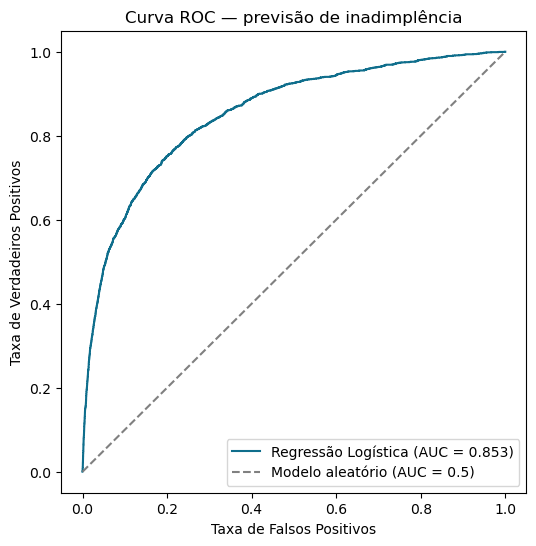

AUC: 0.8533


In [11]:
from sklearn.metrics import roc_curve, roc_auc_score

X_test_sm = sm.add_constant(X_test, has_constant='add')
y_pred_proba = modelo_logit.predict(X_test_sm)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='#0f6e8c', label=f'Regressão Logística (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Modelo aleatório (AUC = 0.5)')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC — previsão de inadimplência')
plt.legend()
plt.show()

print(f"AUC: {auc:.4f}")

### Índice de Gini

No mercado de crédito, o resultado da curva ROC costuma ser reportado como **Gini**, não como
AUC — é a métrica padrão em validação de modelos de score (inclusive referenciada em normas
regulatórias bancárias, ex: Basileia). A relação entre os dois é direta:

`Gini = 2 × AUC − 1`

Geometricamente, é duas vezes a área entre a curva ROC e a linha diagonal (o modelo aleatório) —
mede o quanto o modelo se afasta do acaso.

In [12]:
gini = 2 * auc - 1
print(f"AUC: {auc:.4f}")
print(f"Gini: {gini:.4f}")

AUC: 0.8533
Gini: 0.7066


## 12. Matriz de confusão

Usando o limiar padrão de 0,5 (probabilidade prevista ≥ 0,5 → classifica como inadimplente).

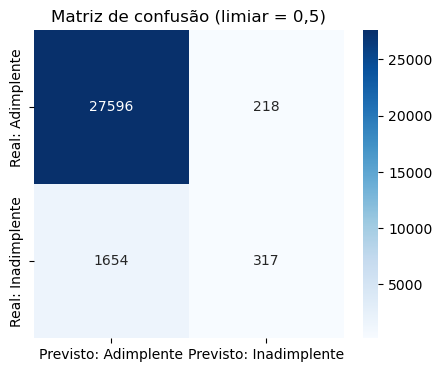

              precision    recall  f1-score   support

  Adimplente       0.94      0.99      0.97     27814
Inadimplente       0.59      0.16      0.25      1971

    accuracy                           0.94     29785
   macro avg       0.77      0.58      0.61     29785
weighted avg       0.92      0.94      0.92     29785



In [13]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = (y_pred_proba >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Previsto: Adimplente', 'Previsto: Inadimplente'],
            yticklabels=['Real: Adimplente', 'Real: Inadimplente'])
plt.title('Matriz de confusão (limiar = 0,5)')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Adimplente', 'Inadimplente']))

## 13. Conclusões

**AUC = 0,853** — o modelo tem boa capacidade de separar quem vai inadimplir de quem não vai,
bem acima do modelo aleatório (0,5).

**Achado honesto sobre o limiar de 0,5:** apesar do AUC bom, o `classification_report` mostra
que, no limiar padrão, o modelo captura só **16% dos inadimplentes reais** (recall de 0,16).
Isso não é o modelo "ruim" — é o efeito clássico de dataset desbalanceado: como só ~7% da base
é inadimplente, o modelo precisa de muita evidência pra cruzar 50% de probabilidade prevista.
Num caso de uso real (ex: decidir quem recusar crédito), o limiar de decisão seria ajustado pra
baixo — aceitando mais falsos positivos em troca de pegar mais inadimplentes de verdade, dado
que o custo de um empréstimo que não é pago costuma ser bem maior que o custo de negar crédito a
alguém que pagaria.

**Odds Ratios — o que mais aumenta o risco:**
- `RevolvingUtilizationOfUnsecuredLines` tem OR = **6,02** — a variável de longe mais forte: cada
  unidade a mais nessa taxa de utilização de crédito multiplica a chance de inadimplência por 6x.
- As três variáveis de histórico de atraso (`NumberOfTimes90DaysLate`, `60-89`, `30-59`) têm OR
  entre 1,5 e 1,9 — confirma o que já se sabe na prática de crédito: histórico de atraso é o
  melhor preditor de atraso futuro.
- `age` tem OR = 0,98 (< 1) — é **protetivo**: quanto mais velho o tomador, menor a chance de
  inadimplência, mantendo tudo mais constante.

**Ressalva de rigor sobre `MonthlyIncome` e `DebtRatio`:** os Odds Ratios dessas duas variáveis
aparecem próximos de 1 (ex: 0,999975), o que pode parecer "sem efeito" — mas isso é um artefato
de escala, não ausência de efeito real. `MonthlyIncome` varia em milhares de dólares; o OR "por
1 dólar" é naturalmente minúsculo. Ao longo de uma faixa realista (ex: R\$1.000 de renda a mais),
o efeito acumulado já é perceptível. Interpretar OR de variáveis contínuas de escala grande
direto pelo valor "por unidade" é um erro comum — o certo seria reportar o efeito por um
incremento maior (ex: a cada R\$1.000) ou padronizar a variável antes de rodar o modelo.

**Conexão com o TCC:** a mesma técnica (Regressão Logística + Odds Ratios) que usei pra entender
comportamento de investidores numa base de 27 milhões de registros aqui identificou, numa base
de 150 mil tomadores, que utilização de crédito e histórico de atraso são os fatores dominantes
de risco — resultado consistente com a literatura de crédito, o que dá confiança de que o
pipeline (tratamento de dados, modelagem, interpretação) está correto.

**Próximos passos possíveis:**
- Testar um modelo baseado em árvore (XGBoost) e comparar o AUC com a regressão logística.
- Ajustar o limiar de decisão explorando a curva precisão-recall, não só a ROC.
- Aplicar a mesma base a técnicas de balanceamento (ex: `class_weight='balanced'` ou SMOTE) e ver
  o impacto no recall da classe minoritária.

## 14. Apêndice: variando o limiar de decisão (0,1 a 0,9)

Continuação do primeiro item de "próximos passos" acima. 0,5 é só a convenção padrão do
`predict()` — não tem nada de especial pra este problema, principalmente sendo desbalanceado.
Varrendo o limiar de 0,1 a 0,9, calculo precisão, recall e F1 em cada ponto pra ver onde fica o
melhor equilíbrio.

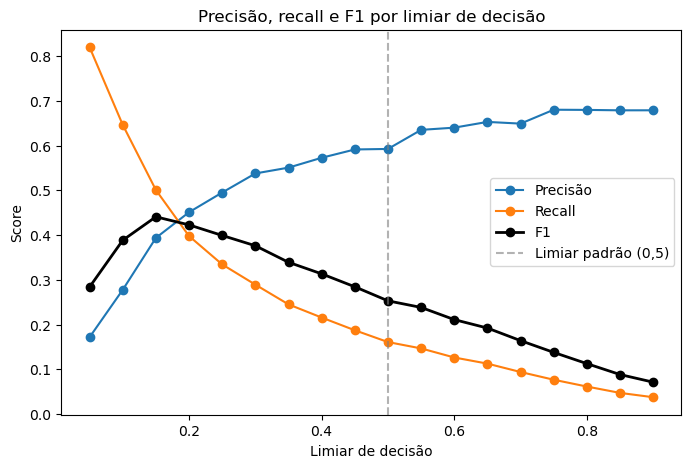

Melhor limiar por F1: 0.15 (precisão=0.394, recall=0.501, F1=0.441)


In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_teste = np.arange(0.05, 0.95, 0.05)
resultados = []
for t in thresholds_teste:
    pred_t = (y_pred_proba >= t).astype(int)
    resultados.append({
        'threshold': round(t, 2),
        'precision': precision_score(y_test, pred_t, zero_division=0),
        'recall': recall_score(y_test, pred_t, zero_division=0),
        'f1': f1_score(y_test, pred_t, zero_division=0),
    })

df_thresholds = pd.DataFrame(resultados)

plt.figure(figsize=(8, 5))
plt.plot(df_thresholds['threshold'], df_thresholds['precision'], marker='o', label='Precisão')
plt.plot(df_thresholds['threshold'], df_thresholds['recall'], marker='o', label='Recall')
plt.plot(df_thresholds['threshold'], df_thresholds['f1'], marker='o', label='F1', linewidth=2, color='black')
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.6, label='Limiar padrão (0,5)')
plt.xlabel('Limiar de decisão')
plt.ylabel('Score')
plt.title('Precisão, recall e F1 por limiar de decisão')
plt.legend()
plt.show()

melhor = df_thresholds.loc[df_thresholds['f1'].idxmax()]
print(f"Melhor limiar por F1: {melhor['threshold']:.2f} (precisão={melhor['precision']:.3f}, recall={melhor['recall']:.3f}, F1={melhor['f1']:.3f})")

**Resultado:** o melhor F1 acontece no limiar **0,15**, não em 0,5 — com precisão de 0,394 e
recall de 0,501. Comparando com o limiar padrão (seção 12): recall salta de **16% para 50%**
(o modelo passa a capturar 3x mais inadimplentes de verdade), ao custo de a precisão cair de
0,59 para 0,39 (mais falsos positivos — gente que não ia inadimplir sendo sinalizada como risco).

**Por que isso faz sentido:** com só ~7% de positivos na base, o modelo raramente empurra a
probabilidade prevista acima de 0,5 mesmo pra casos genuinamente arriscados — a classe majoritária
"puxa" as probabilidades pra baixo. Reduzir o limiar compensa esse efeito.

**Qual limiar é o "certo"?** Depende do custo de negócio, não só de matemática:
- Se o custo de um empréstimo não pago é muito maior que o custo de negar crédito a um bom
  pagador → vale um limiar ainda mais baixo que 0,15, priorizando recall.
- Se o custo de perder clientes bons (falsos positivos) pesa mais → um limiar mais próximo de
  0,5 (ou o F1 ótimo) é mais equilibrado.
- O F1 (que pondera precisão e recall igualmente) é só um ponto de partida neutro — numa
  aplicação real de crédito, o ideal é substituir F1 por uma função de custo com os valores
  reais de cada tipo de erro.